# Baseline Model — Offensive IT-Tester

**Char n-gram TF-IDF + Logistic Regression** on `data/cleaned/dataset_final.jsonl`
(455 attack payloads + 2000 benign CSIC-2010 inputs).

Two tasks:
- **A. attack vs benign** — the input-side detector ("is this an attack?")
- **B. attack_class (5-way)** — the router that picks which `confirm()` oracle validates a payload

This is a *baseline*: a simple, fully-explainable linear model that later work must beat.
It is deliberately **advisory** — the live scanner routes by the dataset's own `type`, so a
model error can never silently drop a real payload.

## 0. Setup

The next cell adds the project root to `sys.path` by walking up until it finds `config/`,
so the notebook imports correctly **whether the kernel starts in `models/` or the repo root**.

In [11]:
import sys
from pathlib import Path

# make the project importable regardless of the kernel's working directory
for _p in [Path.cwd(), *Path.cwd().parents]:
    if (_p / "config" / "paths.py").exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, ConfusionMatrixDisplay)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

import joblib
from config.paths import CLEAN, ROOT
SEED = 42
DATA = CLEAN / "dataset_final.jsonl"
MODELS = ROOT / "models" 

## 1. Load the dataset

One row per input string. The model uses the **`payload`** column only; `label` and
`attack_class` are the two targets.

In [12]:
rows = [json.loads(l) for l in DATA.open(encoding="utf-8")]
df = pd.DataFrame(rows)
print("total:", len(df))
print(df["label"].value_counts().to_dict())
df[["id", "label", "attack_class", "type", "payload", "severity", "oracle"]].head(6)

total: 2455
{'benign': 2000, 'attack': 455}


,id,label,attack_class,type,payload,severity,oracle
0,sqli-001,attack,sqli,tautology,' OR '1'='1,high,differential
1,sqli-002,attack,sqli,union,"' UNION SELECT username, password FROM users--",high,marker_reflection
2,sqli-003,attack,sqli,blind-time,'; WAITFOR DELAY '0:0:5'--,high,timing
3,sqli-004,attack,sqli,error-based,"' AND 1=CONVERT(int,@@version)--",high,error_signature
4,sqli-005,attack,sqli,boolean-blind,' AND 1=1--,high,differential
5,sqli-006,attack,sqli,stacked-queries,'; DROP TABLE users--,critical,timing


## 2. Leakage guards — the most important step

A payload classifier is trivial to cheat:
- `id` literally encodes the class (`sqli-001`) → **never a feature**
- `context_bucket` / `severity` correlate with the label → **never features**
- an exact-duplicate payload in both train and test would leak → **removed here**

So the ONLY feature is the raw payload text.

In [13]:
seen, uniq = set(), []
for r in rows:
    if r["payload"] in seen:
        continue
    seen.add(r["payload"])
    uniq.append(r)
print("rows after exact-duplicate payload removal:", len(uniq))

rows after exact-duplicate payload removal: 2455


## 3. The pipeline

**Char n-grams (2–5)** because payloads are code-like: fragments such as `' OR`,
`<script`, `;`, `../` are the signal — not English words. `class_weight="balanced"`
handles the 1 : 4.4 attack:benign imbalance.

In [14]:
def make_pipeline():
    return Pipeline([
        ("tfidf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5),
                                  min_df=2, sublinear_tf=True)),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced")),
    ])

def split(X, y):
    return train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

## 4. Task A — attack vs benign

A `DummyClassifier` (always predicts the majority class) is the reference every real
model must beat.

In [15]:
Xa = [r["payload"] for r in uniq]
ya = [r["label"] for r in uniq]
Xtr, Xte, ytr, yte = split(Xa, ya)

dummy = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
pipeA = make_pipeline().fit(Xtr, ytr)
predA = pipeA.predict(Xte)

print(f"Dummy    macro-F1: {f1_score(yte, dummy.predict(Xte), average='macro'):.3f}  (reference)")
print(f"Baseline macro-F1: {f1_score(yte, predA, average='macro'):.3f}\n")
print(classification_report(yte, predA, digits=3))

Dummy    macro-F1: 0.449  (reference)
Baseline macro-F1: 0.986

              precision    recall  f1-score   support

      attack      1.000     0.956     0.978       114
      benign      0.990     1.000     0.995       500

    accuracy                          0.992       614
   macro avg      0.995     0.978     0.986       614
weighted avg      0.992     0.992     0.992       614



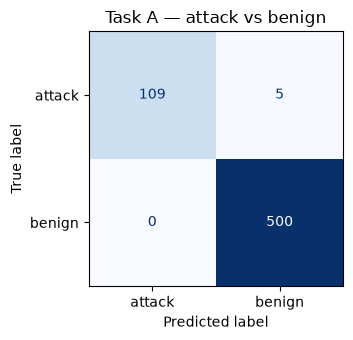

In [16]:
fig, ax = plt.subplots(figsize=(4, 3.5))
ConfusionMatrixDisplay.from_predictions(yte, predA, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Task A — attack vs benign")
plt.tight_layout(); plt.show()

### 4.1 False-negative analysis — where the model fails

0 false positives, but a few **false negatives** (attacks passed off as benign). For a
security tool these are the costly errors. Note *what* evades: exotic URI schemes that
mimic benign data, short Windows commands, and encoded payloads.

In [17]:
Xtr2, Xte2, ytr2, yte2, rtr2, rte2 = train_test_split(
    Xa, ya, uniq, test_size=0.25, random_state=SEED, stratify=ya)
predA2 = make_pipeline().fit(Xtr2, ytr2).predict(Xte2)
fn = [(r["attack_class"], r["type"], r["payload"]) for r, p, t in zip(rte2, predA2, yte2)
      if t == "attack" and p == "benign"]
print(f"false negatives: {len(fn)} / {yte2.count('attack')} hold-out attacks\n")
for cls, typ, pl in fn:
    print(f"  [{cls}/{typ}] {pl[:60]!r}")

false negatives: 5 / 114 hold-out attacks

  [csrf/CSRF] "<script>eval(unescape('%66%6f%72%6d%20%3d%20%64%6f%63%75%6d%"
  [ssrf/SSRF] 'magnet:?xt=urn:btih:abcdef1234567890'
  [cmdi/Command Injection] '&& ipconfig'
  [ssrf/SSRF] 'tel:+1234567890'
  [cmdi/Command Injection] '& reg query HKLM\\Software'


## 5. Task B — attack_class (5-way router)

On attack rows only: predict the family so the execution layer can pick the right oracle.

In [18]:
atk = [r for r in uniq if r["label"] == "attack"]
Xb = [r["payload"] for r in atk]
yb = [r["attack_class"] for r in atk]
Xtr, Xte, ytr, yte = split(Xb, yb)

dummyB = DummyClassifier(strategy="most_frequent").fit(Xtr, ytr)
pipeB = make_pipeline().fit(Xtr, ytr)
predB = pipeB.predict(Xte)

print(f"Dummy    macro-F1: {f1_score(yte, dummyB.predict(Xte), average='macro'):.3f}  (reference)")
print(f"Baseline macro-F1: {f1_score(yte, predB, average='macro'):.3f}\n")
print(classification_report(yte, predB, digits=3))

Dummy    macro-F1: 0.072  (reference)
Baseline macro-F1: 0.991

              precision    recall  f1-score   support

        cmdi      0.957     1.000     0.978        22
        csrf      1.000     1.000     1.000        24
        sqli      1.000     1.000     1.000        22
        ssrf      1.000     0.952     0.976        21
         xss      1.000     1.000     1.000        25

    accuracy                          0.991       114
   macro avg      0.991     0.990     0.991       114
weighted avg      0.992     0.991     0.991       114



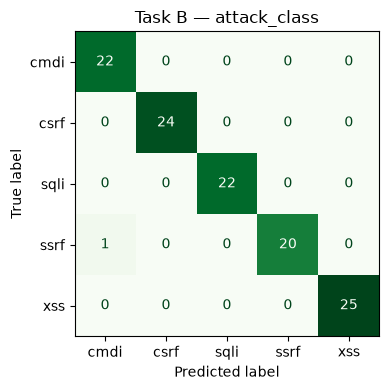

In [19]:
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(yte, predB, ax=ax, colorbar=False, cmap="Greens")
ax.set_title("Task B — attack_class")
plt.tight_layout(); plt.show()

## 6. Persist the trained models

For the saved artifacts we **refit on the full dataset** (train + test) — the hold-out
split above was only for honest evaluation; a deployed model should use all available data.
Saved as `.pkl` for the execution layer to load.

In [20]:
MODELS.mkdir(parents=True, exist_ok=True)

clf_binary = make_pipeline().fit(Xa, ya)              # attack vs benign, all rows
joblib.dump(clf_binary, MODELS / "clf_binary.pkl")

clf_class = make_pipeline().fit(Xb, yb)               # attack_class, attack rows only
joblib.dump(clf_class, MODELS / "clf_attack_class.pkl")

print("saved:")
print("  models/clf_binary.pkl        ", MODELS.joinpath("clf_binary.pkl").exists())
print("  models/clf_attack_class.pkl  ", MODELS.joinpath("clf_attack_class.pkl").exists())

saved:
  models/clf_binary.pkl         True
  models/clf_attack_class.pkl   True


## 7. Fairness evaluation

**What fairness means here.** There are no people in this system, so this isn't about
demographic bias. Fairness means the detector should be **equally good at catching every kind
of attack**. If it catches SQL injection well but misses command injection, then command
injection quietly slips through — and a class the model is weak at is a class that gets
under-tested. That is the harm we're checking for.

**The main finding: the mistakes are one-sided.** The detector never flags a harmless input as
an attack (0 false positives), but it lets **5 real attacks through as if they were harmless**
(false negatives — 4.4% of the attacks it was tested on). For a security tool that's the wrong
way to be wrong: a missed attack is far more dangerous than a false alarm.

**And the misses aren't random — they cluster in SSRF and command injection.** They're the
attacks that are *designed to look innocent*: a payload that reads like a phone number
(`tel:+1234567890`), a rare link type (`magnet:?xt=…`), a short Windows command (`&& ipconfig`),
or one hidden behind hex-encoding. The 5-way router shows the same weak spots — it's essentially
perfect on SQLi, XSS and CSRF, and only stumbles on SSRF and CMDi. So both models are weakest in
the same place, and that's where the real coverage gap is.

**Two honesty notes.** The scores look almost too good because the "normal" training traffic is
clean and very different from attacks — real-world inputs (a surname like `O'Brien`) would be
harder and push accuracy down. And a couple of attack types have very few examples (`error-based`
SQLi has just 4), so we only trust the numbers at the class level, not per individual technique.

## 8. Risk assessment (NIST AI RMF: Map → Measure → Manage)

We walk through the standard three steps: **Map** the risks, say how we **Measure** each, then
how we **Manage** it.

**The biggest risk is trusting the score too much.** The model scores ~0.98–0.99, but only
because today's data is easy — clean, well-separated traffic. That number is a *ceiling*, not a
promise about the real world; a single hex-encoded payload already gets past it. Close behind are
the **missed attacks** from §7 (the 5 false negatives in SSRF/CMDi), which are the costly kind of
error for a security tool.

**Some smaller risks we watched for.** That the model might be cheating by reading the label off a
give-away field (*leakage*) — prevented by training on the payload text only and removing duplicate
payloads. That the 1-attack-to-4-benign imbalance could make plain accuracy look flattering — so we
report per-class scores, never raw accuracy. That real targets won't look like our clean training
data (*distribution shift*). And that a wrong class prediction could send a payload to the wrong
verification check (*mis-routing*).

**How we measure it.** We compare against a dummy model that just guesses the majority class
(0.449 / 0.072) — beating it badly shows the model learns something real — and we track the **4.4%
false-negative rate** as the number that actually matters for security.

**How we manage it.** We treat the F1 score as an upper bound, plan an adversarial test set
(encoded and disguised payloads) before trusting it further, and use balanced class weights. The
most important safeguard: the model is **advisory, not in charge**. The live scanner decides what to
fire from the dataset's own labels, so even if the model misses an attack, it can **never quietly
drop a real payload** — and anything destructive is held for a human to approve regardless.

**Bottom line.** The model looks strong mainly because the data is easy, so we keep it in an
advisory role and treat every score as a best case, not a guarantee.